# Required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.varmax import VARMAX

In [3]:
from typing import Union
from tqdm.notebook import trange
import warnings

# 10.1) Examining the VAR model

In [4]:
macro_data = sm.datasets.macrodata.load_pandas()

In [5]:
macro_econ = macro_data['data']

In [6]:
macro_econ.info()

<class 'pandas.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      203 non-null    float64
 1   quarter   203 non-null    float64
 2   realgdp   203 non-null    float64
 3   realcons  203 non-null    float64
 4   realinv   203 non-null    float64
 5   realgovt  203 non-null    float64
 6   realdpi   203 non-null    float64
 7   cpi       203 non-null    float64
 8   m1        203 non-null    float64
 9   tbilrate  203 non-null    float64
 10  unemp     203 non-null    float64
 11  pop       203 non-null    float64
 12  infl      203 non-null    float64
 13  realint   203 non-null    float64
dtypes: float64(14)
memory usage: 22.3 KB


In [7]:
macro_econ.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [8]:
macro_econ.tail()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19
202,2009.0,3.0,12990.341,9256.0,1486.398,1044.088,10040.6,216.385,1673.9,0.12,9.6,308.013,3.56,-3.44


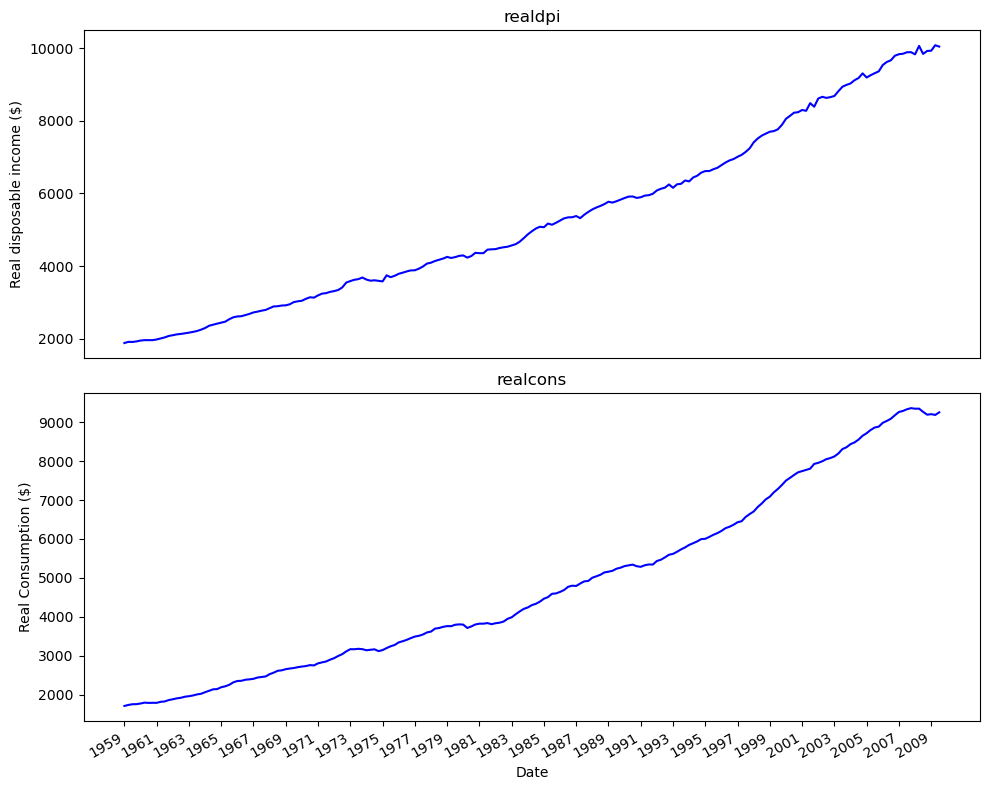

In [9]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)
ax[0].plot(macro_econ['realdpi'], 'b-')
ax[0].set_ylabel('Real disposable income ($)')
ax[0].xaxis.set_ticks_position('none')
ax[0].set_title('realdpi')

ax[1].plot(macro_econ['realcons'], 'b-')
ax[1].set_ylabel('Real Consumption ($)')
ax[1].set_xlabel('Date')
ax[1].set_title('realcons')

ax[1].set_xticks(np.arange(0, 204, 8))
ax[1].set_xticklabels(np.arange(1959, 2011, 2))

fig.autofmt_xdate()
fig.tight_layout()

plt.show()

## checking stationarity

In [10]:
adfuller(macro_econ['realdpi'])

(np.float64(2.9860253519546833),
 1.0,
 2,
 200,
 {'1%': np.float64(-3.463476079125),
  '5%': np.float64(-2.876102355),
  '10%': np.float64(-2.574532225)},
 np.float64(2014.6630929800756))

In [11]:
adfuller(np.diff(macro_econ['realdpi']))

(np.float64(-8.864893340673008),
 np.float64(1.4493606159108096e-14),
 1,
 200,
 {'1%': np.float64(-3.463476079125),
  '5%': np.float64(-2.876102355),
  '10%': np.float64(-2.574532225)},
 np.float64(2009.0790249915815))

In [12]:
adfuller(macro_econ['realcons'])

(np.float64(1.549912338050959),
 np.float64(0.9976992503412904),
 4,
 198,
 {'1%': np.float64(-3.4638151713286316),
  '5%': np.float64(-2.876250632135043),
  '10%': np.float64(-2.574611347821651)},
 np.float64(1793.172616888144))

In [13]:
adfuller(np.diff(macro_econ['realcons']))

(np.float64(-4.204306080845247),
 np.float64(0.0006479282158627571),
 3,
 198,
 {'1%': np.float64(-3.4638151713286316),
  '5%': np.float64(-2.876250632135043),
  '10%': np.float64(-2.574611347821651)},
 np.float64(1784.2903520562793))

In [14]:
endog = macro_econ[['realdpi', 'realcons']].diff().dropna()

## Finding order with AIC

In [15]:
def optimize_VAR(endog: pd.DataFrame, max_order: int=15) -> pd.DataFrame:
    """
    Find the optimum value of p using AIC.

    Params:
    --------
    endog: pd.DataFrame
        A dataframe with numerical columns.

    Returns:
    --------
        A pd.DataFrame object with p and AIC.
    """
    results = []

    for p in trange(max_order):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                model = VARMAX(endog, order=(p, 0)).fit(disp=False)
                results.append([p, model.aic])
        except:
            continue

    return pd.DataFrame(results, columns=['p', 'AIC']).sort_values(by='AIC', ascending=True).reset_index(drop=True)
            

In [16]:
endog.head()

,realdpi,realcons
1,32.8,26.3
2,-3.3,18.1
3,14.9,1.9
4,24.2,16.8
5,10.6,22.4


In [17]:
result_df = optimize_VAR(endog[:162])

  0%|          | 0/15 [00:00<?, ?it/s]

In [18]:
result_df.head()

,p,AIC
0,3,3123.070079
1,5,3123.708523
2,6,3126.855598
3,4,3129.194027
4,2,3130.091668


## Granger casuality tests

In [19]:
endog.columns

Index(['realdpi', 'realcons'], dtype='str')

In [20]:
# realcons Granger causes realdpi
grangercausalitytests(endog.iloc[:, [0, 1]], [3])


Granger Causality
number of lags (no zero) 3
ssr based F test:         F=9.2363  , p=0.0000  , df_denom=192, df_num=3
ssr based chi2 test:   chi2=28.7191 , p=0.0000  , df=3
likelihood ratio test: chi2=26.8268 , p=0.0000  , df=3
parameter F test:         F=9.2363  , p=0.0000  , df_denom=192, df_num=3


{np.int64(3): ({'ssr_ftest': (np.float64(9.236302935003344),
    np.float64(9.771659881004587e-06),
    np.float64(192.0),
    np.int64(3)),
   'ssr_chi2test': (np.float64(28.719129438526025),
    np.float64(2.565354241450447e-06),
    np.int64(3)),
   'lrtest': (np.float64(26.826823124426937),
    np.float64(6.400614700874191e-06),
    np.int64(3)),
   'params_ftest': (np.float64(9.236302935003335),
    np.float64(9.771659881004702e-06),
    np.float64(192.0),
    3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0., 1., 0.]])])}

In [21]:
# realdpi Granger causes realcons
grangercausalitytests(endog.iloc[:, [1, 0]], [3])


Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.8181  , p=0.0403  , df_denom=192, df_num=3
ssr based chi2 test:   chi2=8.7625  , p=0.0326  , df=3
likelihood ratio test: chi2=8.5751  , p=0.0355  , df=3
parameter F test:         F=2.8181  , p=0.0403  , df_denom=192, df_num=3


{np.int64(3): ({'ssr_ftest': (np.float64(2.8180926920793072),
    np.float64(0.04029520008929368),
    np.float64(192.0),
    np.int64(3)),
   'ssr_chi2test': (np.float64(8.762506964434095),
    np.float64(0.03262095244932233),
    np.int64(3)),
   'lrtest': (np.float64(8.575071029579703),
    np.float64(0.03550803145041808),
    np.int64(3)),
   'params_ftest': (np.float64(2.8180926920793166),
    np.float64(0.040295200089293166),
    np.float64(192.0),
    3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0., 1., 0.]])])}

## Fitting the model

In [22]:
train = endog[:162]
test = endog[162:]

In [23]:
best_model = VARMAX(train, order=(3,0)).fit(disp=False)

## Diagnostics

In [24]:
endog.columns

Index(['realdpi', 'realcons'], dtype='str')

### `realdpi` GOF

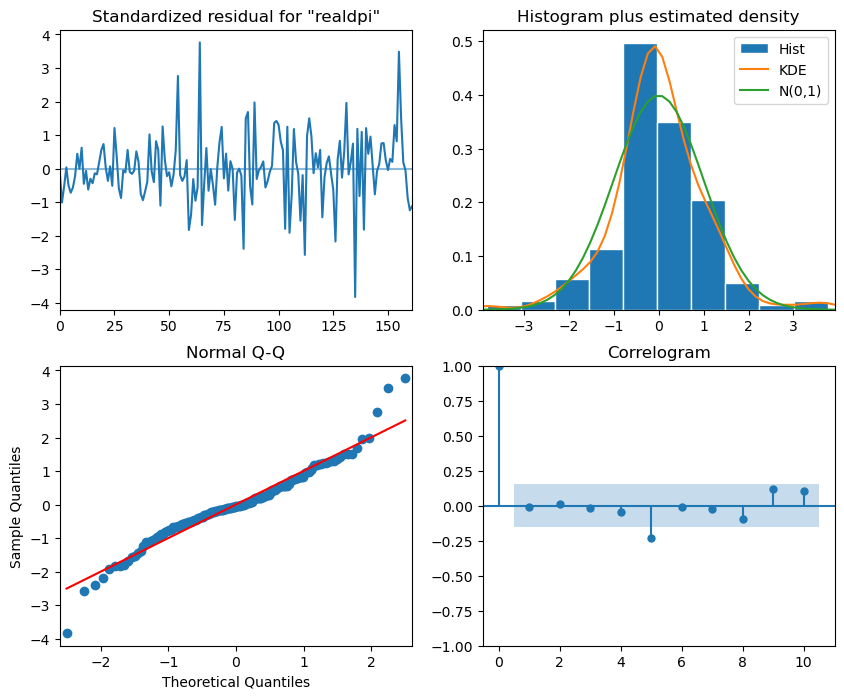

In [25]:
best_model.plot_diagnostics(figsize=(10, 8), variable=0);

In [26]:
best_model.resid


,realdpi,realcons
1,-4.288838,-9.190387
2,-36.105197,-13.728254
3,-18.599672,-22.946484
4,1.339240,-5.144734
5,-17.612521,1.992652
...,...,...
158,6.610259,17.849501
159,-1.873267,35.353056
160,-30.742553,-12.249443
161,-43.538357,40.637637


In [27]:
df_lb_realdpi = acorr_ljungbox(best_model.resid['realdpi'], lags=20)
df_lb_realdpi

,lb_stat,lb_pvalue
1,0.011616,0.914172
2,0.029354,0.985430
3,0.075777,0.994577
4,0.377911,0.984245
5,9.142671,0.103507
6,9.165503,0.164482
7,9.270262,0.233830
8,10.811769,0.212594
9,13.318300,0.148724
10,15.287604,0.121923


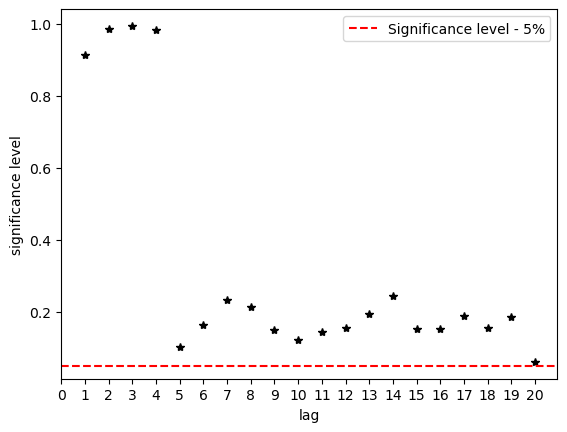

In [28]:
fig, ax = plt.subplots()
ax.plot(df_lb_realdpi['lb_pvalue'], 'k*')
ax.set_ylabel('significance level')
ax.set_xlabel('lag')
ax.set_xticks(np.arange(21))
ax.axhline(0.05, color='red', linestyle='dashed', label='Significance level - 5%')
ax.legend(loc='upper right')
plt.show()

### `realcons` GOF

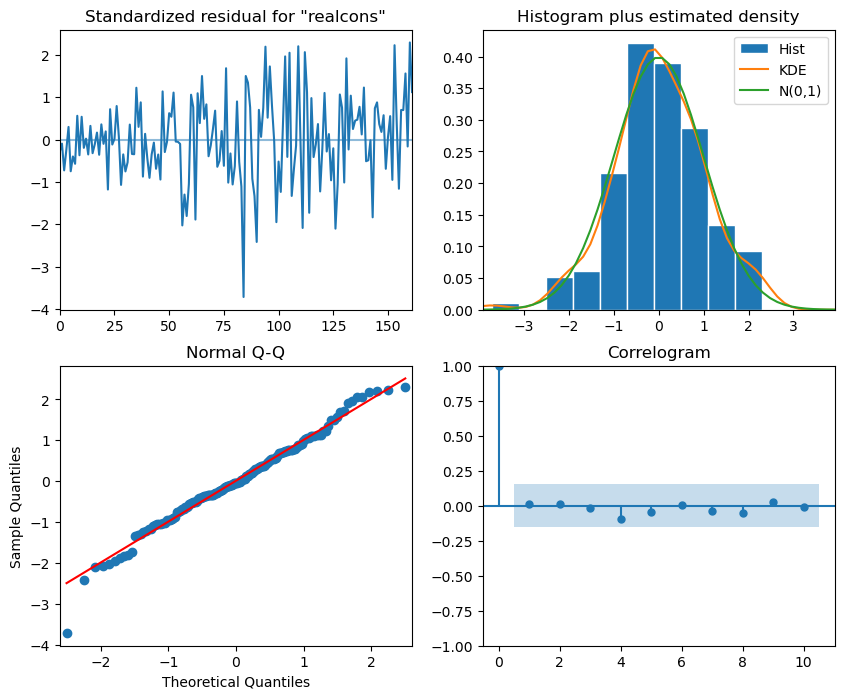

In [29]:
best_model.plot_diagnostics(figsize=(10, 8), variable=1);

In [30]:
df_lb_realcons = acorr_ljungbox(best_model.resid['realcons'], lags=20)

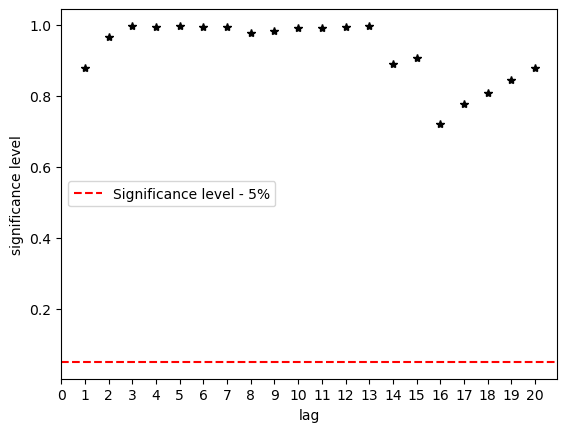

In [31]:
fig, ax = plt.subplots()
ax.plot(df_lb_realcons['lb_pvalue'], 'k*')
ax.set_ylabel('significance level')
ax.set_xlabel('lag')
ax.set_xticks(np.arange(21))
ax.axhline(0.05, color='red', linestyle='dashed', label='Significance level - 5%')
ax.legend(loc='center left')
plt.show()

In [32]:
test.shape

(40, 2)

# 10.3) Forecasting real disposable and real consumption

## Rolling Forecast

In [33]:
def rolling_forecast(data: pd.DataFrame, train_len: int, horizon: int, window: int,
                    method: str, order: Union[tuple, list] = (3, 0)) -> pd.DataFrame:
    """
    Rolling forecast for VAR model.

    Params:
    -------
    data: pd.DataFrame
        DataFrame with target time series.
    train_len: int
        Train size.
    horizon: int,
        Numbers of steps ahead to be predicted.
    window: int,
        Number of steps to be predicted at each iteration.
    method: str
        Method used to make the predictions. Must be 'var' (for VAR model) or 'last' (for last value baseline model).

    Returns:
    --------
        A dataframe with horizon rows and the same number of columns of data.
    """

    if method not in ('var', 'last'):
        raise ValueError('method must be or "var" either "last".')

    total_len = train_len + horizon

    realdpi = []
    realcons = []
    
    if method == 'var':
        for i in trange(train_len, total_len, window, desc='var'):
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    model = VARMAX(data[:i], order=order).fit(disp=False)
                    predictions = model.get_prediction(0, i + window - 1)
                    realdpi.extend(predictions.predicted_mean.iloc[-window:].loc[:, 'realdpi'].values)
                    realcons.extend(predictions.predicted_mean.iloc[-window:].loc[:, 'realcons'].values)
            except:
                continue
    elif method == 'last':
        for i in trange(train_len, total_len, window, desc='last'):
            realdpi.extend(data[:i].iloc[-1].loc['realdpi'] for _ in range(window))
            realcons.extend(data[:i].iloc[-1].loc['realcons'] for _ in range(window))

    return pd.DataFrame({
        'realdpi_pred': realdpi,
        'realdpi_true': data.loc[train_len:, 'realdpi'],
        'realcons_pred': realcons,
        'realcons_true': data.loc[train_len:, 'realcons'],
    }, index=data.index[train_len:])
            

In [34]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 4
df_pred_var = rolling_forecast(
    endog, TRAIN_LEN, HORIZON, WINDOW, 'var' 
)

var:   0%|          | 0/10 [00:00<?, ?it/s]

In [35]:
df_pred_var.head()

,realdpi_pred,realdpi_true,realcons_pred,realcons_true
163,63.324207,121.8,67.926040,102.8
164,67.964186,165.7,75.931537,112.1
165,63.374091,82.5,66.374616,70.5
166,54.193806,86.4,59.986699,74.1
167,65.952220,12.3,74.386816,67.6


In [36]:
df_pred_last = rolling_forecast(
    endog, TRAIN_LEN, HORIZON, WINDOW, 'last'
)

last:   0%|          | 0/10 [00:00<?, ?it/s]

In [37]:
df_pred_last.head()

,realdpi_pred,realdpi_true,realcons_pred,realcons_true
163,49.9,121.8,86.5,102.8
164,49.9,165.7,86.5,112.1
165,49.9,82.5,86.5,70.5
166,49.9,86.4,86.5,74.1
167,86.4,12.3,74.1,67.6


## Integration

In [38]:
integration = lambda pred, initial_value: initial_value + np.cumsum(pred)

In [39]:
df_pred_integrated = pd.DataFrame({
    'pred_last_realcons': integration(df_pred_last['realcons_pred'], macro_econ.loc[162, 'realcons']),
    'pred_var_realcons': integration(df_pred_var['realcons_pred'], macro_econ.loc[162, 'realcons']),
    'realcons': integration(test['realcons'], macro_econ.loc[162, 'realcons']),
    'pred_last_realdpi': integration(df_pred_last['realdpi_pred'], macro_econ.loc[162, 'realdpi']),
    'pred_var_realdpi': integration(df_pred_var['realdpi_pred'], macro_econ.loc[162, 'realdpi']),
    'realdpi': integration(test['realdpi'], macro_econ.loc[162, 'realdpi']),
})

In [40]:
df_pred_integrated.head()

,pred_last_realcons,pred_var_realcons,realcons,pred_last_realdpi,pred_var_realdpi,realdpi
163,7372.9,7354.326040,7389.2,7815.8,7829.224207,7887.7
164,7459.4,7430.257576,7501.3,7865.7,7897.188393,8053.4
165,7545.9,7496.632192,7571.8,7915.6,7960.562484,8135.9
166,7632.4,7556.618891,7645.9,7965.5,8014.756290,8222.3
167,7706.5,7631.005707,7713.5,8051.9,8080.708510,8234.6


## Plotting the forecasts

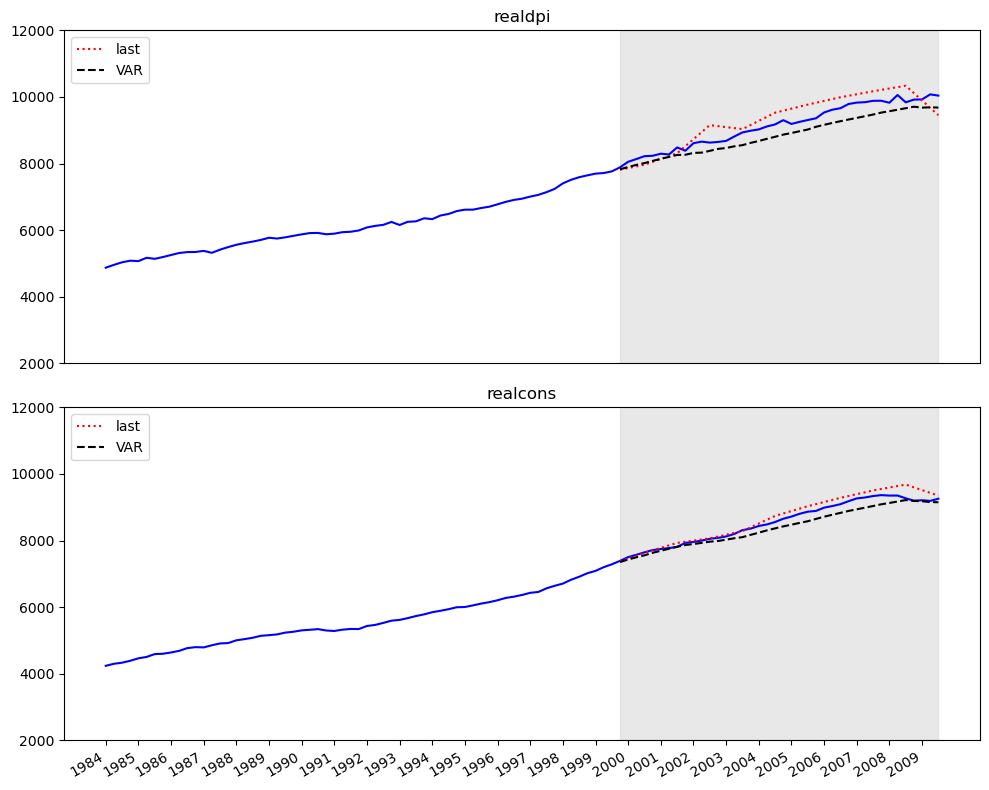

In [41]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10,8), sharex=True)
ax[0].plot(macro_econ.loc[100:, 'realdpi'], 'b-')
ax[0].plot(df_pred_integrated['pred_last_realdpi'], 'r:', label='last')
ax[0].plot(df_pred_integrated['pred_var_realdpi'], 'k--', label='VAR')
ax[0].axvspan(df_pred_integrated.index[0], df_pred_integrated.index[-1], color='lightgray', alpha=0.5)
ax[0].xaxis.set_ticks_position('none')
ax[0].set_title('realdpi')
ax[0].legend(loc='upper left')
ax[0].set_ylim([2000, 12000])

ax[1].plot(macro_econ.loc[100:, 'realcons'], 'b-')
ax[1].plot(df_pred_integrated['pred_last_realcons'], 'r:', label='last')
ax[1].plot(df_pred_integrated['pred_var_realcons'], 'k--', label='VAR')
ax[1].axvspan(df_pred_integrated.index[0], df_pred_integrated.index[-1], color='lightgray', alpha=0.5)
ax[1].set_title('realcons')
ax[1].set_ylim([2000, 12000])
ax[1].legend(loc='upper left')
ax[1].set_xticks(macro_econ.index[100::4])
ax[1].set_xticklabels(macro_data['data'].loc[100::4, 'year'].astype(np.int64))

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## MAPE

In [42]:
mape = lambda y, p: 100 * np.mean(np.abs((y - p) / y))

In [43]:
df_pred_integrated.head()

,pred_last_realcons,pred_var_realcons,realcons,pred_last_realdpi,pred_var_realdpi,realdpi
163,7372.9,7354.326040,7389.2,7815.8,7829.224207,7887.7
164,7459.4,7430.257576,7501.3,7865.7,7897.188393,8053.4
165,7545.9,7496.632192,7571.8,7915.6,7960.562484,8135.9
166,7632.4,7556.618891,7645.9,7965.5,8014.756290,8222.3
167,7706.5,7631.005707,7713.5,8051.9,8080.708510,8234.6


In [44]:
mape_realdpi = pd.Series({
    'last': mape(df_pred_integrated['realdpi'], df_pred_integrated['pred_last_realdpi']),
    'VAR':  mape(df_pred_integrated['realdpi'], df_pred_integrated['pred_var_realdpi'])
})
mape_realcons = pd.Series({
    'last': mape(df_pred_integrated['realcons'], df_pred_integrated['pred_last_realcons']),
    'VAR': mape(df_pred_integrated['realcons'],df_pred_integrated['pred_var_realcons'])
})

In [45]:
mape_realdpi

last    3.139693
VAR     3.138216
dtype: float64

In [46]:
mape_realcons

last    1.461569
VAR     1.770942
dtype: float64

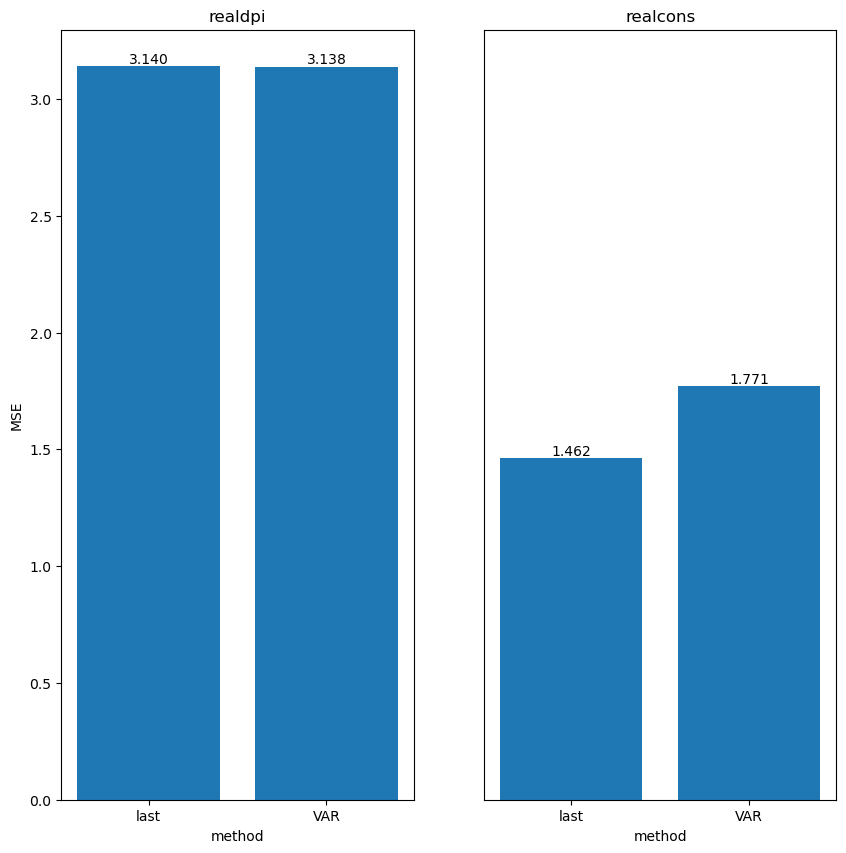

In [47]:
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10,10))
bars = ax[0].bar(mape_realdpi.index, mape_realdpi.values)
ax[0].bar_label(bars, fmt='%.3f')
ax[0].set_title('realdpi')
ax[0].set_xlabel('method')
ax[0].set_ylabel('MSE')

bars = ax[1].bar(mape_realcons.index, mape_realcons.values)
ax[1].bar_label(bars, fmt='%.3f')
ax[1].set_title('realcons')
ax[1].set_xlabel('method')
ax[1].yaxis.set_ticks_position('none')
ax[1].set_title('realcons')

plt.show()

We shouldn't use the varmax model in this context.